### BlBibliotecas Essenciais

In [ ]:
import pandas as pd
import kagglehub
import os
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, classification_report

# Baixa os dados
path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")

# Carrega as duas tabelas principais
pedidos = pd.read_csv(os.path.join(path, "olist_orders_dataset.csv"))
notas = pd.read_csv(os.path.join(path, "olist_order_reviews_dataset.csv"))

# Une as tabelas (Merge)
df = pd.merge(pedidos, notas[['order_id', 'review_score']], on='order_id')

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")

print("Path to dataset files:", path)

In [54]:
pip install kagglehub pandas

Note: you may need to restart the kernel to use updated packages.


### Visualizando a base

In [55]:
import pandas as pd
import os

# 1. Carregar a tabela de pedidos (orders)
# O 'path' é a variável que você criou no passo anterior
df_pedidos = pd.read_csv(os.path.join(path, "olist_orders_dataset.csv"))

# 2. Carregar a tabela de notas (reviews)
df_notas = pd.read_csv(os.path.join(path, "olist_order_reviews_dataset.csv"))

# 3. Criar a 'base_dados' unindo as duas tabelas pelo ID do pedido
# Isso é o que chamamos de MERGE
base_dados = pd.merge(df_pedidos, df_notas[['order_id', 'review_score']], on='order_id')

# 4. Agora sim, este comando vai funcionar!
print("Sucesso! Base de dados criada.")
base_dados.head()

Sucesso! Base de dados criada.


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,4
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,4
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,5
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,5
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,5


In [56]:
print(base_dados.shape)

(99224, 9)


In [57]:
print(base_dados.dtypes)

order_id                           str
customer_id                        str
order_status                       str
order_purchase_timestamp           str
order_approved_at                  str
order_delivered_carrier_date       str
order_delivered_customer_date      str
order_estimated_delivery_date      str
review_score                     int64
dtype: object


### Tratamento de Datas e Criação de Colunas

In [58]:
# 1. Converter para formato de data
cols_data = ['order_purchase_timestamp', 'order_delivered_customer_date', 'order_estimated_delivery_date']
for col in cols_data:
    df[col] = pd.to_datetime(df[col])

# 2. Criar colunas numéricas (em dias)
# Tempo que levou para entregar
df['tempo_entrega_real'] = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.days

# Dias de atraso (positivo = atrasou | negativo = adiantou)
df['dias_atraso'] = (df['order_delivered_customer_date'] - df['order_estimated_delivery_date']).dt.days

# 3. Remover valores nulos (pedidos não entregues ou sem nota)
df = df.dropna(subset=['tempo_entrega_real', 'dias_atraso', 'review_score'])

### Limpeza de Outliers

In [59]:
# Filtro manual: Entregas entre 0 e 90 dias e atrasos plausíveis
df_limpo = df[(df['tempo_entrega_real'] >= 0) & (df['tempo_entrega_real'] <= 90)]
df_limpo = df_limpo[df_limpo['dias_atraso'] >= -30]

# Criar alvo da Logística (1 = Satisfeito: notas 4 e 5 | 0 = Insatisfeito: notas 1, 2 e 3)
df_limpo['satisfeito'] = df_limpo['review_score'].apply(lambda x: 1 if x >= 4 else 0)

print(f"Dados prontos! Total de linhas: {len(df_limpo)}")

Dados prontos! Total de linhas: 93931


In [60]:
# Definindo X (causas) e y (consequências)
X = df_limpo[['tempo_entrega_real', 'dias_atraso']]
y_lin = df_limpo['review_score']
y_log = df_limpo['satisfeito']

# Divisão Treino e Teste (80% para aprender, 20% para testar)
X_train, X_test, y_train_lin, y_test_lin = train_test_split(X, y_lin, test_size=0.2, random_state=42)
_, _, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.2, random_state=42)

# --- REGRESSÃO LINEAR ---
modelo_linear = LinearRegression()
modelo_linear.fit(X_train, y_train_lin)
pred_lin = modelo_linear.predict(X_test)

# --- REGRESSÃO LOGÍSTICA ---
modelo_log = LogisticRegression()
modelo_log.fit(X_train, y_train_log)
pred_log = modelo_log.predict(X_test)

print("Modelos treinados com sucesso!")

Modelos treinados com sucesso!


1. Gráfico de Regressão Linear (A Reta de Tendência)

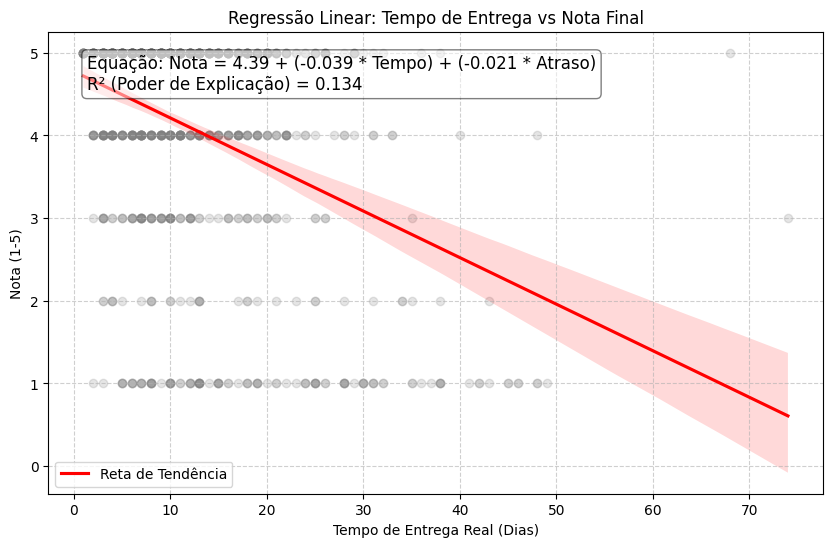

In [61]:
import numpy as np
from sklearn.metrics import r2_score

# 1. Calcular o R² e os Coeficientes
r2 = r2_score(y_test_lin, pred_lin)
intercepto = modelo_linear.intercept_
coef_entrega = modelo_linear.coef_[0]
coef_atraso = modelo_linear.coef_[1]

# 2. Criar o texto da equação
# Formato: y = a + b1*X1 + b2*X2
texto_equacao = (f'Equação: Nota = {intercepto:.2f} + ({coef_entrega:.3f} * Tempo) + ({coef_atraso:.3f} * Atraso)\n'
                 f'R² (Poder de Explicação) = {r2:.3f}')

# 3. Plotar o Gráfico
plt.figure(figsize=(10, 6))

# Usando amostra para não travar o gráfico
df_sample = df_limpo.sample(1000, random_state=42)

# Gráfico de dispersão com a reta de regressão
sns.regplot(data=df_sample, x='tempo_entrega_real', y='review_score', 
            scatter_kws={'alpha':0.2, 'color': 'gray'}, 
            line_kws={'color':'red', 'label': 'Reta de Tendência'})

# Inserir o texto da equação no gráfico
# Os números 0.05 e 0.95 posicionam o texto no canto superior esquerdo
plt.text(0.05, 0.95, texto_equacao, transform=plt.gca().transAxes, 
         fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

plt.title('Regressão Linear: Tempo de Entrega vs Nota Final')
plt.xlabel('Tempo de Entrega Real (Dias)')
plt.ylabel('Nota (1-5)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
!pip install statsmodels

### 2. Gráfico de Regressão Logística (Probabilidade de Satisfação)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# 1. Definindo o X (as causas) e o y (o alvo da satisfação)
# Certifique-se de que a célula do df_limpo foi rodada antes!
X = df_limpo[['tempo_entrega_real', 'dias_atraso']]
y_log = df_limpo['satisfeito']

# 2. Dividindo os dados (80% treino, 20% teste)
X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.2, random_state=42)

# 3. Treinando o modelo logístico (O nascimento do 'modelo_log')
modelo_log = LogisticRegression()
modelo_log.fit(X_train_log, y_train_log)

print("Sucesso! Agora o 'X' e o 'modelo_log' estão prontos.")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Criar dados para a linha da curva (Eixo X: Atraso)
dias_eixo_x = np.linspace(df_limpo['dias_atraso'].min(), df_limpo['dias_atraso'].max(), 300)
media_tempo = df_limpo['tempo_entrega_real'].mean()

# 2. Criar DataFrame para a previsão (evita o UserWarning)
X_visual_df = pd.DataFrame({
    'tempo_entrega_real': [media_tempo] * 300,
    'dias_atraso': dias_eixo_x
})

# 3. Calcular as probabilidades
probabilidades = modelo_log.predict_proba(X_visual_df)[:, 1]

# 4. Plotar o gráfico
plt.figure(figsize=(10, 6))

# Pontos cinzas são os pedidos reais (amostra)
sns.scatterplot(data=df_limpo.sample(500, random_state=42), 
                x='dias_atraso', y='satisfeito', alpha=0.3, color='gray', label='Pedidos Reais')

# Linha verde é a previsão do modelo
plt.plot(dias_eixo_x, probabilidades, color='green', linewidth=3, label='Chance de Satisfação')

# Linha vermelha é o "Dia D" (Promessa de entrega)
plt.axvline(0, color='red', linestyle='--', label='Prazo Prometido')

plt.title('Regressão Logística: Probabilidade de Satisfação vs. Atraso')
plt.xlabel('Dias de Atraso')
plt.ylabel('Probabilidade (0.0 a 1.0)')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

### Matriz de Confusão

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

# 1. Fazer as previsões usando o conjunto de teste (X_test_log)
# Isso cria a variável 'pred_log' que estava faltando
pred_log = modelo_log.predict(X_test_log)

# 2. Calcular a acurácia para você dizer na banca
acuracia = accuracy_score(y_test_log, pred_log)
print(f"Acurácia do Modelo: {acuracia:.2%}")

# 3. Gerar a matriz de confusão
cm = confusion_matrix(y_test_log, pred_log)

# 4. Plotar o gráfico
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Insatisfeito', 'Satisfeito'])
disp.plot(cmap='Greens', values_format='d', ax=ax)

plt.title('Matriz de Confusão: O que o Modelo previu vs Realidade')
plt.grid(False) # Remove as linhas de grade para o gráfico ficar limpo
plt.show()